In [1]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata_new.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

from HubbardTweezer.Hubbard.lattice import sqr_lattice

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([4, 4]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
nmask

615

1000 samples from V_offset = [0.95 1.05], ~50 success

1000 samples from V_ofset = [0.98 1.02], ~5500 success

Note: they are unsorted and mixed

Text(0, 0.5, 'U')

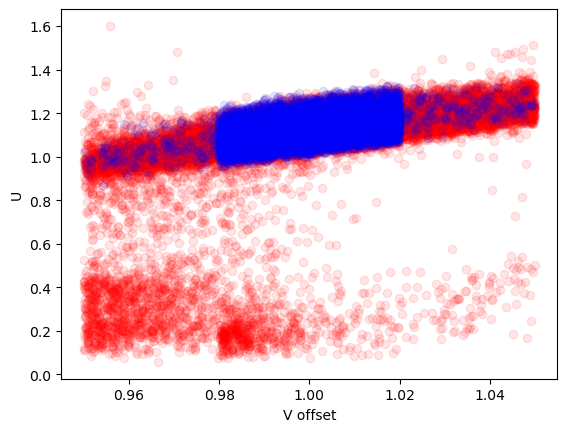

In [3]:
plt.scatter(dat["V_offset"][~mask].flatten(), dat["U_i"][~mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["V_offset"][mask].flatten(), dat["U_i"][mask].flatten(), color='b', alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

Text(0, 0.5, 'U')

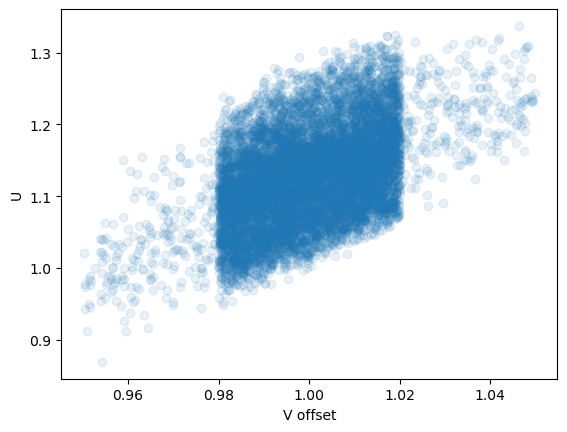

In [3]:
plt.scatter(dat["V_offset"][mask].flatten(), dat["U_i"][mask].flatten(), alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

(-0.05, 0.7)

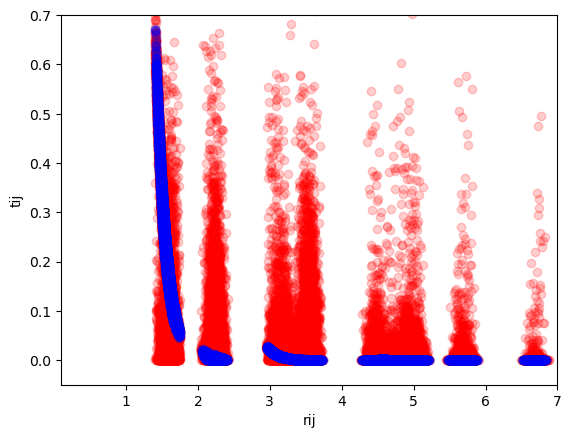

In [4]:
plt.scatter(dat["rij"][~mask].flatten(), dat["t_ij"][~mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["rij"][mask].flatten(), dat["t_ij"][mask].flatten(), color='b', alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

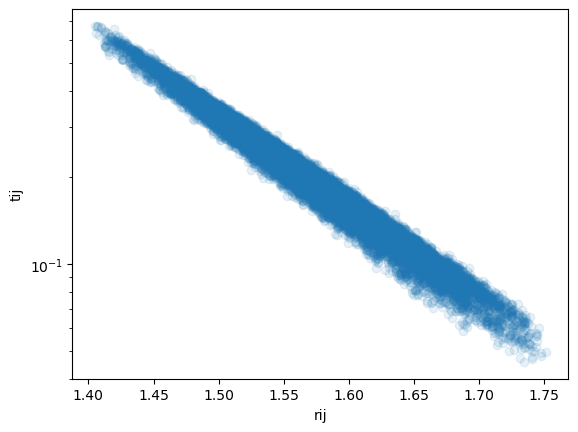

In [8]:
# plt.scatter(nnr[~mask].flatten(), nnt[~mask].flatten(), color='r', alpha=0.1)
# plt.scatter(nnr[mask].flatten(), nnt[mask].flatten(), color='b', alpha=0.1)
plt.scatter(nnr[mask].flatten(), nnt[mask].flatten(), alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

`wf_cost` is the final cost function values in Wannierization. `total_cost_func` is the variance sum of the Hubbard parameters.

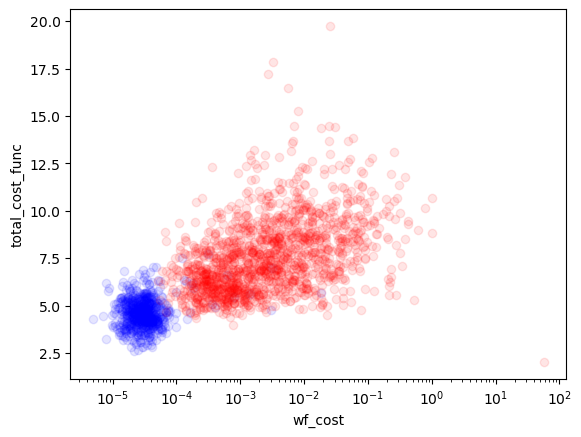

In [6]:
plt.scatter(
    dat["wf_cost"][mask].flatten(),
    dat["total_cost_func"][mask].flatten(),
    color="b",
    alpha=0.1,
)
plt.scatter(
    dat["wf_cost"][~mask].flatten(),
    dat["total_cost_func"][~mask].flatten(),
    color="r",
    alpha=0.1,
)
plt.xlabel("wf_cost")
plt.ylabel("total_cost_func")
plt.xscale("log")

### Correlation to geometric factors

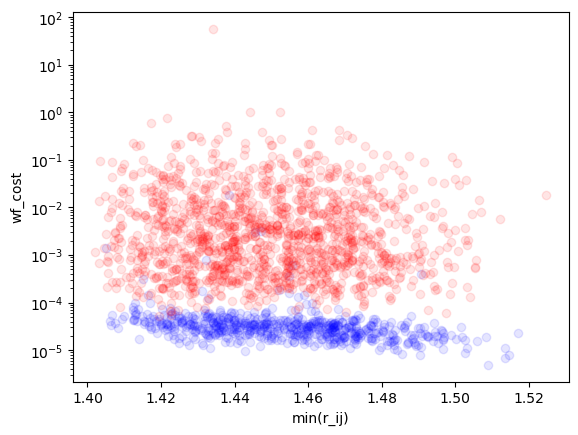

In [7]:
# rmin = dat["rij"] + np.eye(N) * 100
# rmin = np.min(rmin, axis=(1, 2))
rmin = np.min(nnr, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("min(r_ij)")
plt.ylabel("wf_cost")
plt.yscale("log")

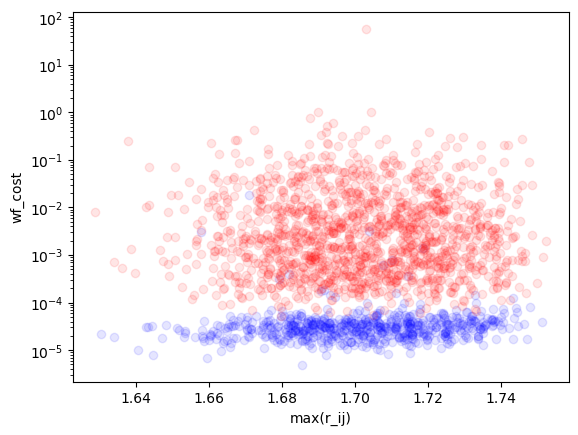

In [8]:
# rmin = dat["rij"]
# rmin = np.max(rmin, axis=(1, 2))
rmin = np.max(nnr, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("max(r_ij)")
plt.ylabel("wf_cost")
plt.yscale("log")

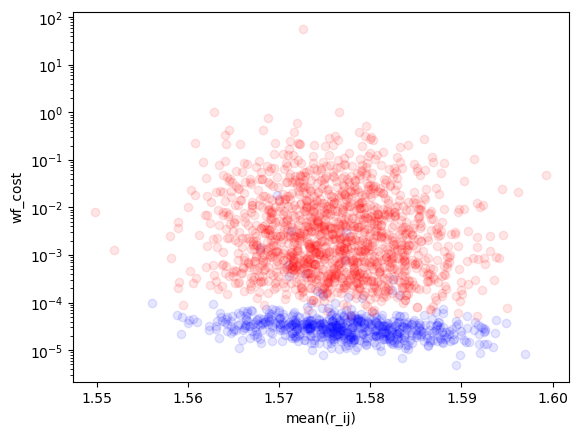

In [9]:
# rmin = dat["rij"]
# rmin = np.mean(rmin, axis=(1, 2))
rmin = np.mean(nnr, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("mean(r_ij)")
plt.ylabel("wf_cost")
plt.yscale("log")

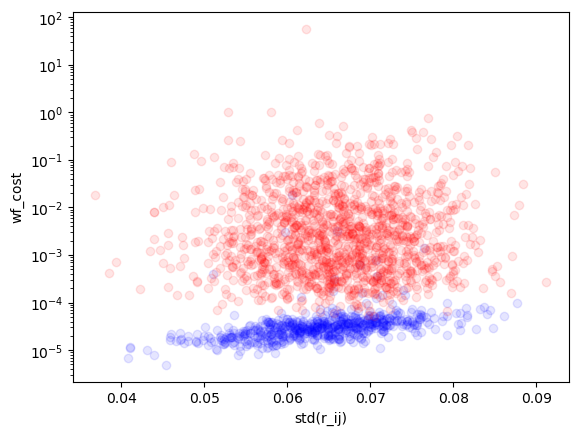

In [10]:
# rmin = dat["rij"]
# rmin = np.mean(rmin, axis=(1, 2))
rmin = np.std(nnr, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("std(r_ij)")
plt.ylabel("wf_cost")
plt.yscale("log")

A slight linear dependence on successful samples.

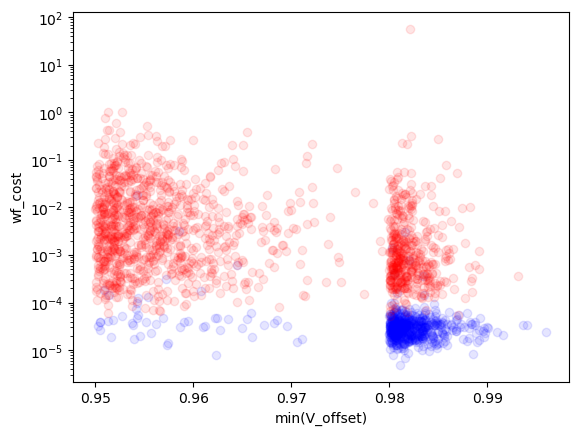

In [11]:
rmin = dat["V_offset"]
rmin = np.min(rmin, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("min(V_offset)")
plt.ylabel("wf_cost")
plt.yscale("log")

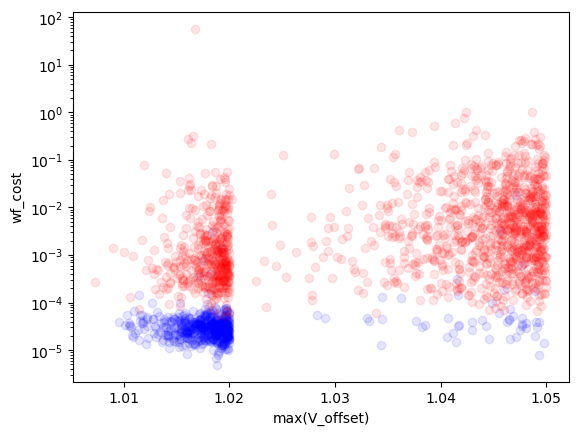

In [12]:
rmin = dat["V_offset"]
rmin = np.max(rmin, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("max(V_offset)")
plt.ylabel("wf_cost")
plt.yscale("log")

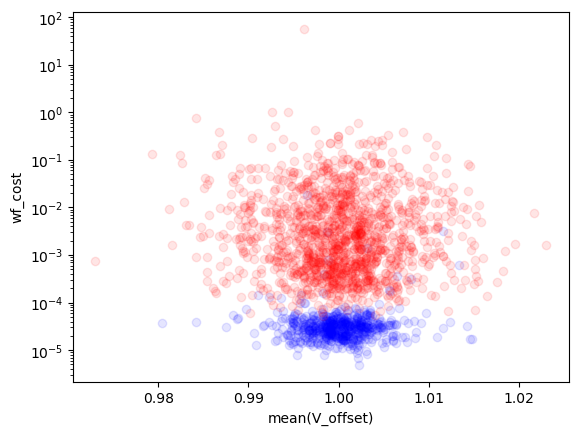

In [23]:
rmin = dat["V_offset"]
rmin = np.mean(rmin, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("mean(V_offset)")
plt.ylabel("wf_cost")
plt.yscale("log")

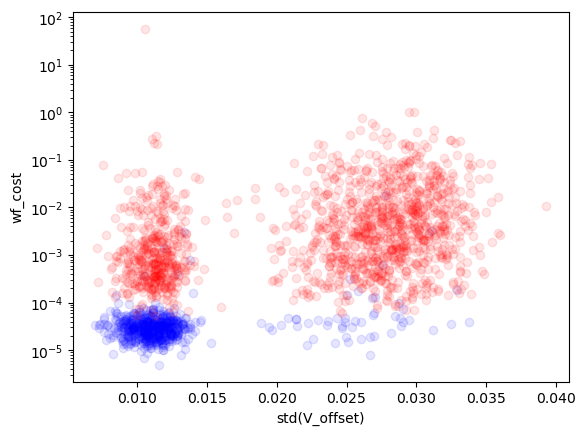

In [14]:
rmin = dat["V_offset"]
rmin = np.std(rmin, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("std(V_offset)")
plt.ylabel("wf_cost")
plt.yscale("log")

Wannierization failure doesn't seem to be clearly relevant to any single geometric factor.

What if I pile `wf_cost` and compare it with all `rij`?

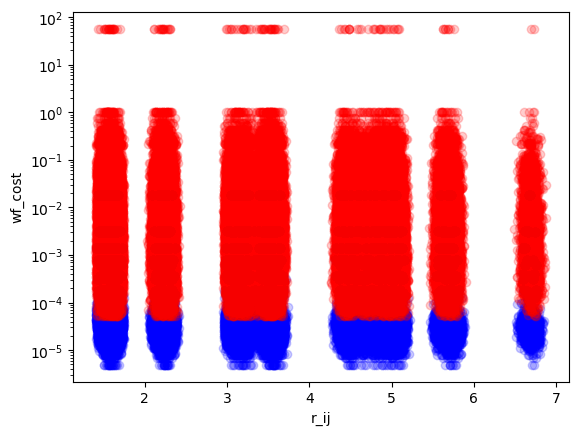

In [15]:
rmin = dat["rij"]
# Creating a mask that excludes the diagonal
offdiag = np.ones((N, N), dtype=bool)
np.fill_diagonal(offdiag, 0)

# Flattening the array
rmin = rmin.reshape(rmin.shape[0], -1)[:, offdiag.ravel()]
wfc = np.tile(dat["wf_cost"], (N**2 - N, 1)).T

plt.scatter(rmin[mask].flatten(), wfc[mask].flatten(), color="b", alpha=0.1)
plt.scatter(rmin[~mask].flatten(), wfc[~mask].flatten(), color="r", alpha=0.1)
plt.xlabel("r_ij")
plt.ylabel("wf_cost")
plt.yscale("log")

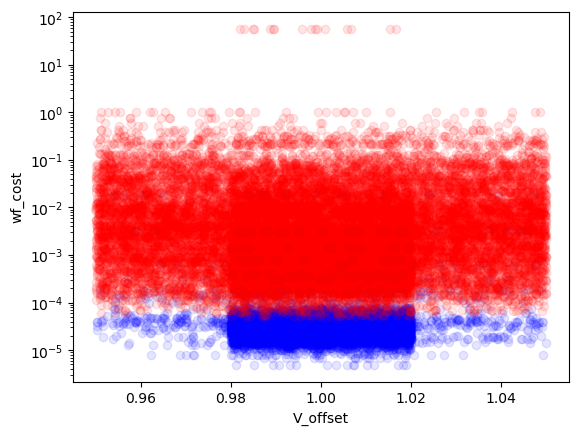

In [16]:
rmin = dat["V_offset"]
wfc = np.tile(dat["wf_cost"], (N, 1)).T

plt.scatter(rmin[mask].flatten(), wfc[mask].flatten(), color="b", alpha=0.1)
plt.scatter(rmin[~mask].flatten(), wfc[~mask].flatten(), color="r", alpha=0.1)
plt.xlabel("V_offset")
plt.ylabel("wf_cost")
plt.yscale("log")

No clear distinction on how geometric factors are distributed with higer or lower wf_cost.

### Correlation to Hubbard parameters

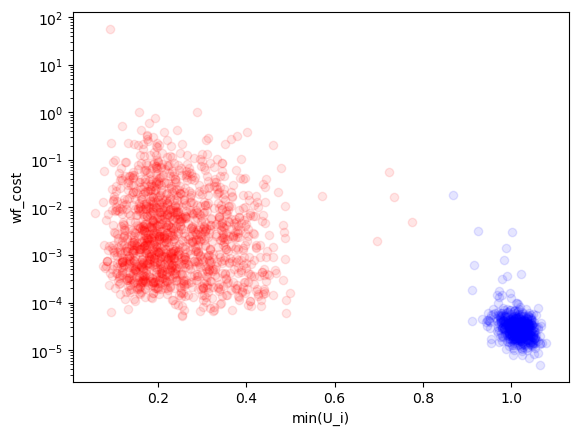

In [17]:
rmin = np.min(dat["U_i"], axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("min(U_i)")
plt.ylabel("wf_cost")
plt.yscale("log")

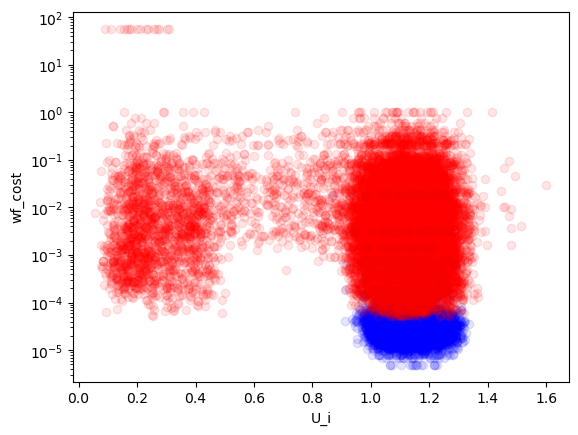

In [18]:
rmin = dat["U_i"]
wfc = np.tile(dat["wf_cost"], (N, 1)).T

plt.scatter(rmin[mask].flatten(), wfc[mask].flatten(), color="b", alpha=0.1)
plt.scatter(rmin[~mask].flatten(), wfc[~mask].flatten(), color="r", alpha=0.1)
plt.xlabel("U_i")
plt.ylabel("wf_cost")
plt.yscale("log")

The key difference between successful and failed Wannierization is min(U_i).

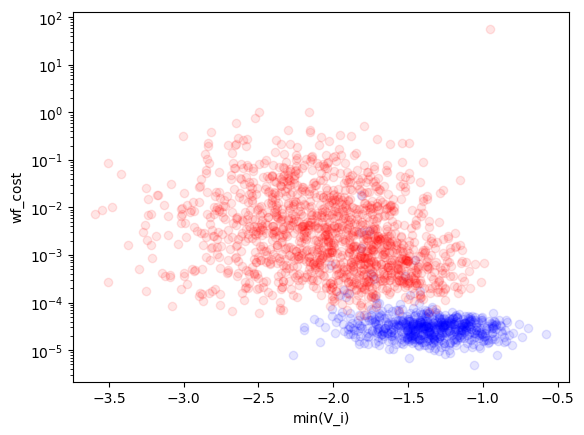

In [19]:
tij = dat["t_ij"]
rmin = np.min(tij, axis=(1, 2))

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("min(V_i)")
plt.ylabel("wf_cost")
plt.yscale("log")

Wannierization failure can be seen much easilier from the Hubbard parameter anomalies.

Success samples are too few that the clusters cannot be well identified.

TODO:
1. Check if fix one parameter the correlation is clearer
2. Do PBC

#### Check what is special about success samples

The success sample with largest `wf_cost`:

In [26]:
id = np.argmax(dat["wf_cost"][mask])
id

487

In [27]:
dat["V_offset"][mask][id]

array([0.98789334, 1.0393441 , 0.95633002, 1.02372939, 1.02426605,
       0.96042826, 0.96501628, 1.00522672, 0.99879464, 1.00468324,
       0.95422374, 1.04714533, 1.01368658, 0.99211486, 0.98399546,
       0.98675026])

In [28]:
dat["wf_cost"][mask][id]

0.01860337895326478

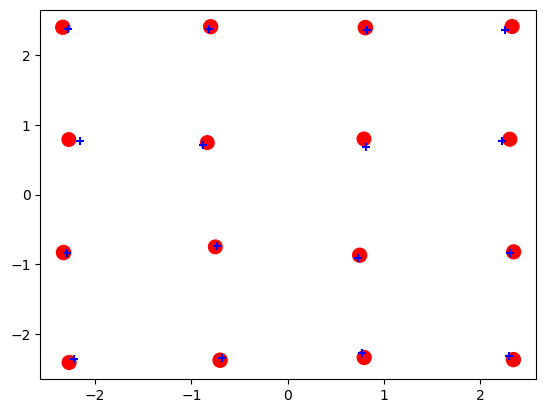

In [29]:
plt.scatter(
    dat["trap_centers"][mask][id, :, 0],
    dat["trap_centers"][mask][id, :, 1],
    c="r",
    s=dat["V_offset"][mask][id] * 100,
    marker="o",
)
plt.scatter(
    dat["wf_centers"][mask][id, :, 0],
    dat["wf_centers"][mask][id, :, 1],
    c="b",
    marker="+",
)

In the above case, the success sample has `wf_cost~0.01` which is much larger than other failed cases.

The failed case with the smallest `wf_cost`:

In [30]:
id = np.argmin(dat["wf_cost"][~mask])
id

515

In [31]:
dat["wf_cost"][~mask][id]

5.198639342163531e-05

In [32]:
dat["U_i"][~mask][id]

array([1.27483156, 1.14551477, 1.08011359, 1.23675719, 1.10100891,
       1.06970601, 1.0260729 , 1.11437805, 1.09367364, 1.10484542,
       1.06499535, 1.11240791, 1.26621269, 1.16976246, 1.23825035,
       0.25300356])

In [33]:
dat["V_offset"][~mask][id]

array([0.99541485, 0.99404967, 0.98335491, 1.00418733, 0.98010361,
       0.99971118, 0.98695744, 1.0038401 , 0.98786108, 1.01373065,
       0.99812712, 1.002048  , 1.01123794, 1.00756525, 1.0197228 ,
       0.98420956])

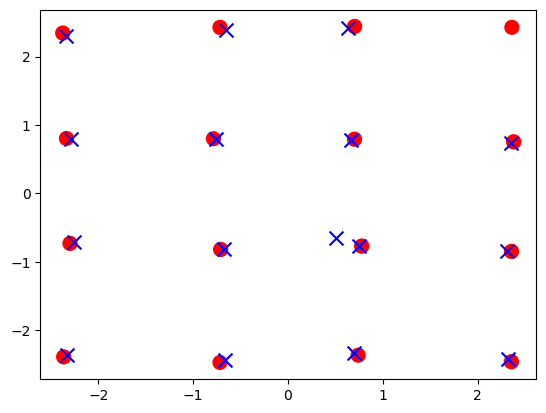

In [34]:
plt.scatter(
    dat["trap_centers"][~mask][id, :, 0],
    dat["trap_centers"][~mask][id, :, 1],
    c="r",
    s=dat["V_offset"][~mask][id] * 100,
    marker="o",
)
plt.scatter(
    dat["wf_centers"][~mask][id, :, 0],
    dat["wf_centers"][~mask][id, :, 1],
    s=100,
    c="b",
    marker="x",
)

Similar conclusion holds.

So `wf_cost` is not a good indicator of success, rather `min(U_ij)` is.

### Test min(U_i) dependence on geometric factors

Text(0, 0.5, 'min(U_i)')

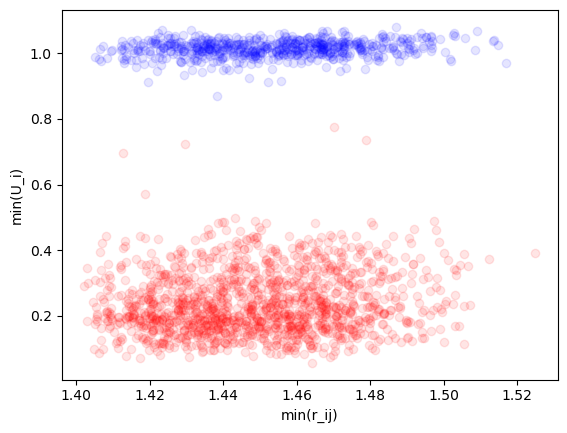

In [40]:
# rmin = dat["rij"] + np.eye(N) * 100
# rmin = np.min(rmin, axis=(1, 2))
rmin = np.min(nnr, axis=1)
minu = np.min(dat["U_i"], axis=1)

plt.scatter(rmin[mask], minu[mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], minu[~mask], color="r", alpha=0.1)
plt.xlabel("min(r_ij)")
plt.ylabel("min(U_i)")
# plt.yscale("log")

Text(0, 0.5, 'min(U_i)')

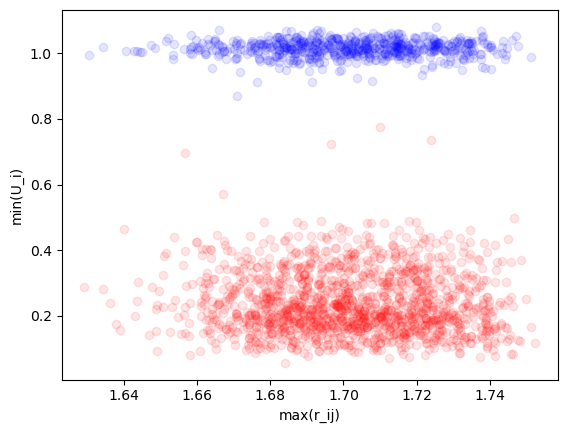

In [39]:
# rmin = dat["rij"] + np.eye(N) * 100
# rmin = np.min(rmin, axis=(1, 2))
rmin = np.max(nnr, axis=1)
minu = np.min(dat["U_i"], axis=1)

plt.scatter(rmin[mask], minu[mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], minu[~mask], color="r", alpha=0.1)
plt.xlabel("max(r_ij)")
plt.ylabel("min(U_i)")
# plt.yscale("log")

Text(0, 0.5, 'min(U_i)')

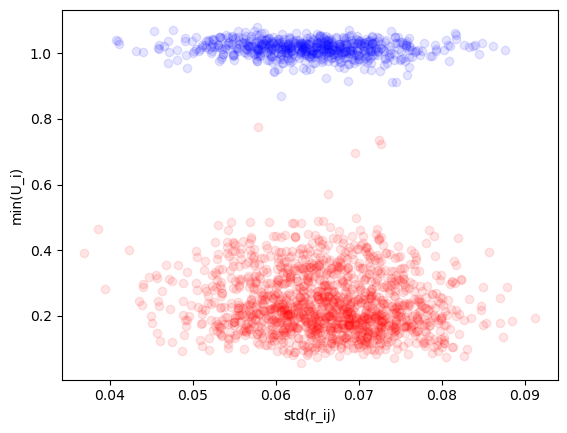

In [41]:
# rmin = dat["rij"]
# rmin = np.mean(rmin, axis=(1, 2))
rmin = np.std(nnr, axis=1)
minu = np.min(dat["U_i"], axis=1)

plt.scatter(rmin[mask], minu[mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], minu[~mask], color="r", alpha=0.1)
plt.xlabel("std(r_ij)")
plt.ylabel("min(U_i)")
# plt.yscale("log")

Text(0, 0.5, 'min(U_i)')

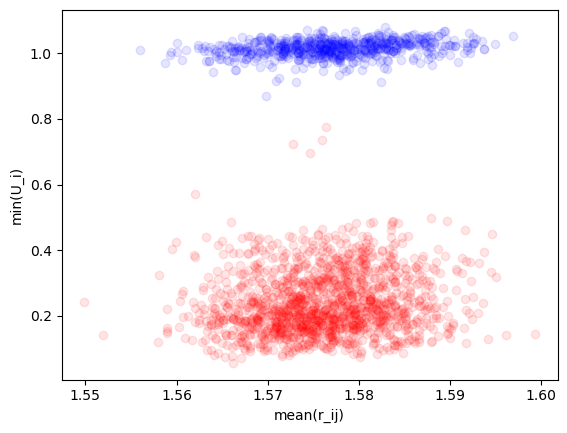

In [3]:
# rmin = dat["rij"]
# rmin = np.mean(rmin, axis=(1, 2))
rmin = np.mean(nnr, axis=1)
minu = np.min(dat["U_i"], axis=1)

plt.scatter(rmin[mask], minu[mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], minu[~mask], color="r", alpha=0.1)
plt.xlabel("mean(r_ij)")
plt.ylabel("min(U_i)")
# plt.yscale("log")

Text(0, 0.5, 'min(U_i)')

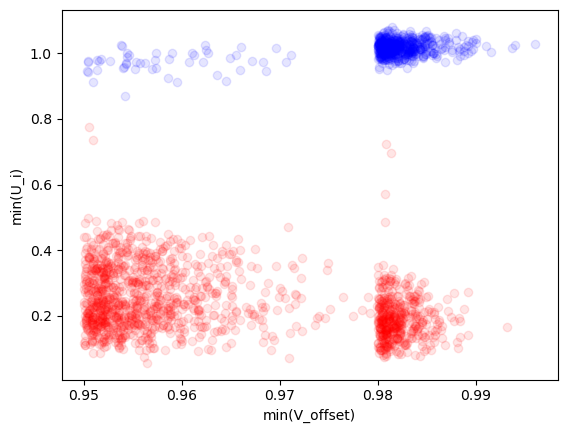

In [45]:
rmin = dat["V_offset"]
rmin = np.min(rmin, axis=1)
minu = np.min(dat["U_i"], axis=1)

plt.scatter(rmin[mask], minu[mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], minu[~mask], color="r", alpha=0.1)
plt.xlabel("min(V_offset)")
plt.ylabel("min(U_i)")
# plt.yscale("log")

Text(0, 0.5, 'min(U_i)')

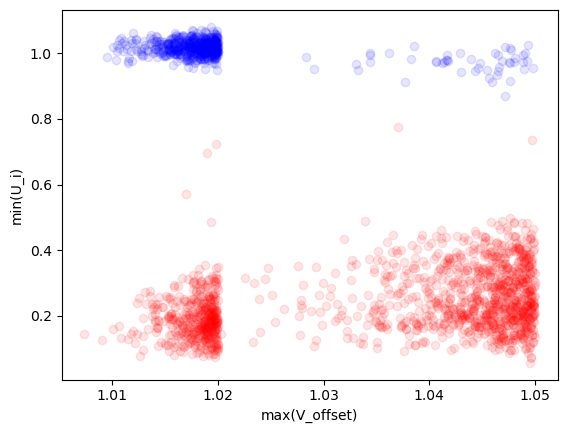

In [47]:
rmin = dat["V_offset"]
rmin = np.max(rmin, axis=1)
minu = np.min(dat["U_i"], axis=1)

plt.scatter(rmin[mask], minu[mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], minu[~mask], color="r", alpha=0.1)
plt.xlabel("max(V_offset)")
plt.ylabel("min(U_i)")
# plt.yscale("log")

Text(0, 0.5, 'min(U_i)')

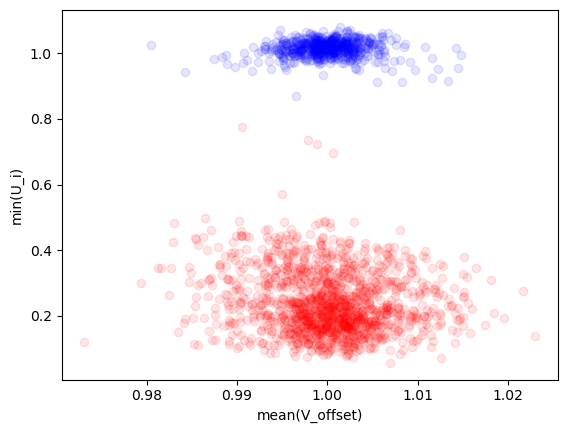

In [5]:
rmin = dat["V_offset"]
rmin = np.mean(rmin, axis=1)
minu = np.min(dat["U_i"], axis=1)

plt.scatter(rmin[mask], minu[mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], minu[~mask], color="r", alpha=0.1)
plt.xlabel("mean(V_offset)")
plt.ylabel("min(U_i)")
# plt.yscale("log")

Text(0, 0.5, 'min(U_i)')

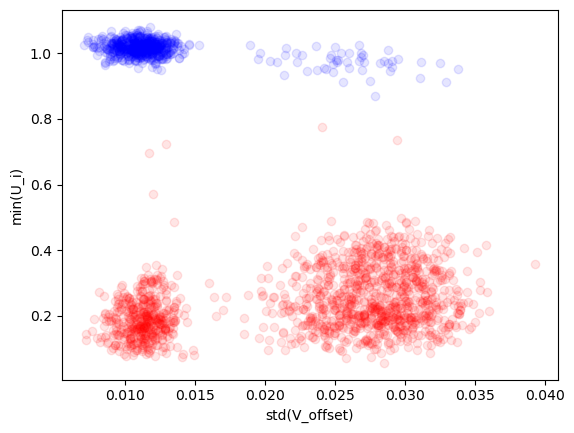

In [6]:
rmin = dat["V_offset"]
rmin = np.std(rmin, axis=1)
minu = np.min(dat["U_i"], axis=1)

plt.scatter(rmin[mask], minu[mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], minu[~mask], color="r", alpha=0.1)
plt.xlabel("std(V_offset)")
plt.ylabel("min(U_i)")
# plt.yscale("log")